In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [8]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# С1 и С2 по отдельности

In [9]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [10]:
model_start_time = time.time()
model_name = 'sberbank-ai/ruBert-large'
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
    label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
)

model = model.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [11]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [12]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [13]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,1.047600,0.943310
2,0.577200,0.916733
3,0.227700,1.461569
4,0.054200,1.924854
5,0.004800,2.077142


Обучение завершено за 524.92 секунд (0:08:44)


In [14]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [15]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.6676
F1 Micro: 0.6676
F1 Macro: 0.6530
F1 Weighted: 0.6637
MAE: 0.4061


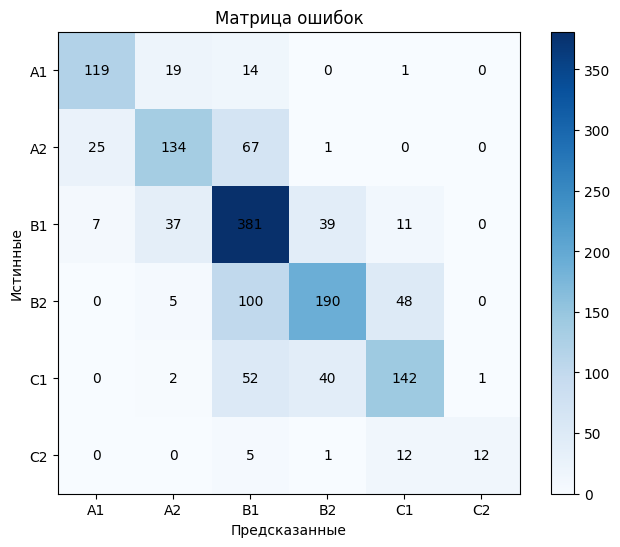

In [16]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [17]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.6676
0.6676
0.6530
0.6637
0.4061
524.92


# Сохранение модели

In [18]:
checkpoint_path = "rubert_sber.pt"

id2label = {
    0: "A1",
    1: "A2",
    2: "B1",
    3: "B2",
    4: "C1",
    5: "C2"
}
label2id = {v: k for k, v in id2label.items()}

base_model_name = 'sberbank-ai/ruBert-large'  

torch.save({
    "model_state_dict": model.state_dict(),
    "base_model_name": base_model_name,
    "num_labels": model.config.num_labels,
    "id2label": id2label,
    "label2id": label2id,
    "max_length": 512
}, checkpoint_path)

print(f"Модель сохранена в {checkpoint_path}")

Модель сохранена в rubert_sber.pt


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(checkpoint_path, map_location=device)

base_model_name = checkpoint["base_model_name"]
num_labels = checkpoint["num_labels"]
id2label = checkpoint["id2label"]
label2id = checkpoint["label2id"]
max_length = checkpoint.get("max_length", 512)

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Модель успешно загружена")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель успешно загружена


In [20]:
def predict_level(text, model, tokenizer, device, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()

    pred_label = model.config.id2label[pred_id]

    return pred_label

In [21]:
def predict_level_and_confidence(text, model, tokenizer, device, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()

    pred_label = model.config.id2label[pred_id]

    pred_conf = probs[0, pred_id].item()

    all_probs = {
        model.config.id2label[i]: float(probs[0, i].item())
        for i in range(probs.shape[1])
    }

    return {
        "predicted_label": pred_label,
        "confidence": pred_conf,
        "probabilities": all_probs
    }

In [22]:
times = []

for text in df['fragment']:
    start = time.time()
    result = predict_level(text, model, tokenizer, device)
    end = time.time()

    times.append(end-start)

In [23]:
min(times), max(times), sum(times) / len(times)

(0.00405573844909668, 0.0067958831787109375, 0.0041535655776844165)

# Объединенные С1 и С2

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df['label'] = df['label'].replace(6, 5)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,5
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,5
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,5
7320,Mapillary использует программное обеспечение д...,6,5


In [5]:
model_start_time = time.time()
model_name = 'sberbank-ai/ruBert-large'
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label={1: 'A1', 2: 'A2', 3: 'B1', 4: 'B2', 5: 'C1'},
    label2id={'A1': 1, 'A2': 2, 'B1': 3, 'B2': 4, 'C1': 5}
)

model = model.to(device)
print(f"Модель инициализирована")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sberbank-ai/ruBert-large
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you exp

Модель инициализирована


In [6]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [7]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [8]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,0.915176,0.878417
2,0.511307,0.862184
3,0.171882,1.500071
4,0.046674,1.811358
5,0.016560,1.941605


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Обучение завершено за 516.57 секунд (0:08:36)


In [20]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [21]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.6287
F1 Micro: 0.6287
F1 Macro: 0.6212
F1 Weighted: 0.6215
MAE: 0.4587


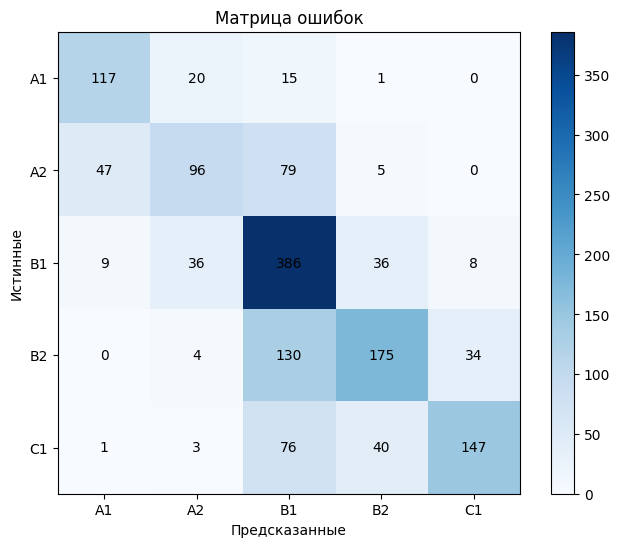

In [22]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [23]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.6287
0.6287
0.6212
0.6215
0.4587
518.25
